# Entraînement final — EfficientNet-B0

Ce notebook :

1. lit automatiquement la meilleure configuration produite par `hyperparameter_search.py`,
2. réentraîne EfficientNet-B0 sur **l'intégralité du pool d'entraînement** (train+validation concaténés),
3. sauvegarde le modèle final dans `results/efficientnet/final_model/`.

Le jeu de test final n'est **pas** touché ici — il sera utilisé uniquement dans `evaluate.ipynb`.

/media/DATA/Projects/bellinna/Zoidberg2.0/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


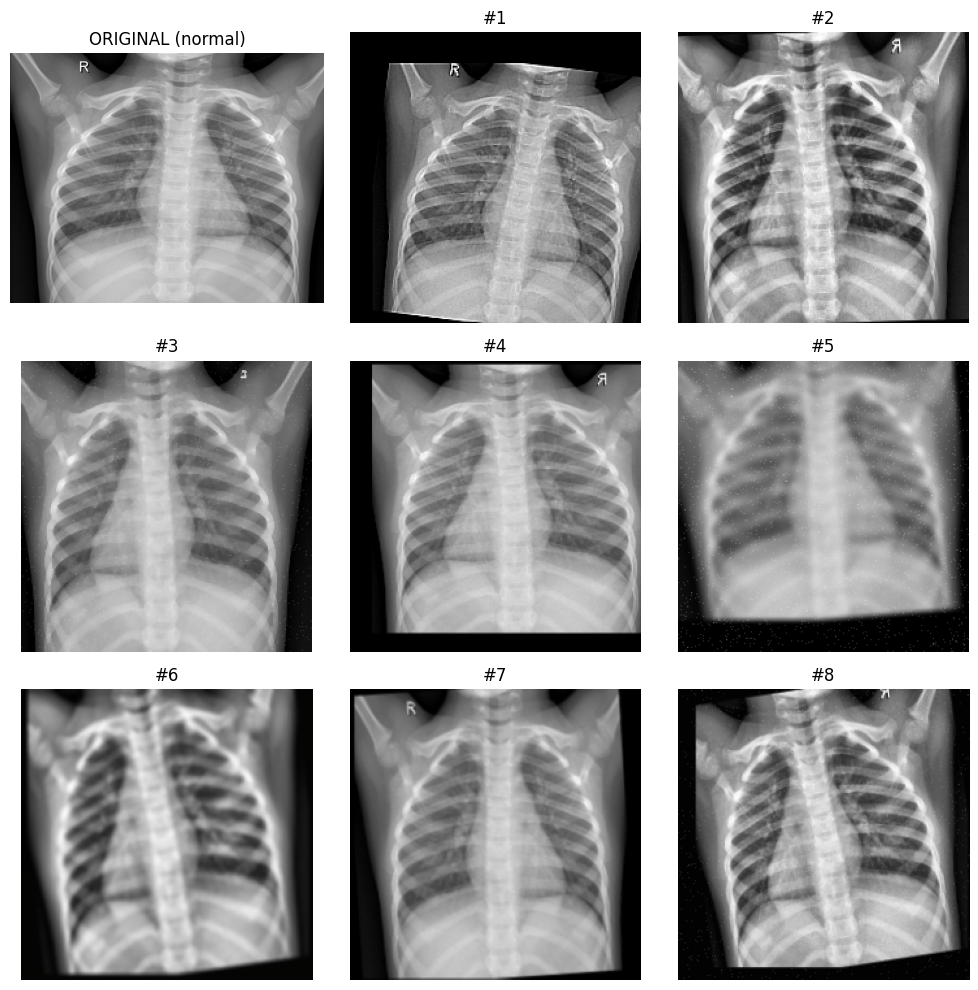

Device: cuda


In [1]:
import gc, json, sys
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from tqdm.auto import tqdm

ROOT = Path.cwd().resolve()
while not (ROOT / "cross_validation.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ipynb.fs.full.preprocessing import get_data_pipeline

FINAL_DIR = ROOT / "results" / "efficientnet" / "final_model"
FINAL_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = ROOT / "results" / "efficientnet" / "hyperparameter_search" / "best_config.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

## 1. Lecture de la meilleure configuration

La configuration provient directement du fichier JSON produit par la recherche d'hyperparamètres.

In [2]:
with open(BEST_PATH) as f:
    best = json.load(f)
cfg = best["best_config"]
print("Meilleure configuration :")
print(json.dumps(cfg, indent=2))
print("\nMétriques CV associées :")
print(json.dumps(best["best_metrics"], indent=2))

Meilleure configuration :
{
  "learning_rate": 0.0001,
  "batch_size": 32,
  "num_epochs": 8,
  "transfer_learning": true
}

Métriques CV associées :
{
  "accuracy_mean": 0.8369989717768895,
  "precision_mean": 0.8355091524850117,
  "recall_mean": 0.8310671080859605,
  "f1_mean": 0.8303065339902229
}


## 2. Préparation des données

On entraîne sur **tout** le pool train+validation. Pas de split de validation interne ici : la sélection des hyperparamètres a déjà été faite par CV.

In [3]:
pipeline = get_data_pipeline()
train_view = pipeline["train_pool_train_view"]
print(f"Pool d'entraînement final : {len(train_view)} images")

train_loader = DataLoader(
    train_view,
    batch_size=cfg["batch_size"],
    shuffle=True,
    num_workers=8,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

Pool d'entraînement final : 5227 images


## 3. Construction du modèle

Implémentation **unifiée** : `transfer_learning=True` charge les poids ImageNet, `False` initialise aléatoirement.

In [4]:
NUM_CLASSES = 3
weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if cfg["transfer_learning"] else None
model = efficientnet_b0(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
print("Modèle prêt.")

Modèle prêt.


## 4. Boucle d'entraînement

On entraîne `num_epochs` epochs en conservant l'historique de la loss pour le rapport.

In [5]:
history = {"train_loss": []}
for epoch in range(1, cfg["num_epochs"] + 1):
    model.train()
    running = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{cfg['num_epochs']}", leave=False):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    epoch_loss = running / len(train_loader.dataset)
    history["train_loss"].append(epoch_loss)
    print(f"Epoch {epoch} | train_loss={epoch_loss:.4f}")

Epoch 1/8:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 1 | train_loss=0.7084


Epoch 2/8:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 2 | train_loss=0.5551


Epoch 3/8:   0%|          | 0/164 [00:00<?, ?it/s]

...

Epoch 6 | train_loss=0.4321


Epoch 7/8:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 7 | train_loss=0.4013


Epoch 8/8:   0%|          | 0/164 [00:00<?, ?it/s]

Epoch 8 | train_loss=0.3984


## 5. Sauvegarde du modèle final

Poids + métadonnées sauvegardés dans `results/efficientnet/final_model/`.

In [6]:
model_path = FINAL_DIR / "efficientnet_b0_final.pt"
torch.save(model.state_dict(), model_path)

meta = {
    "model": "EfficientNetB0",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "config": cfg,
    "train_pool_size": len(train_view),
    "history": history,
    "weights_file": model_path.name,
}
with open(FINAL_DIR / "train_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Modèle : {model_path}")
print(f"Méta   : {FINAL_DIR / 'train_meta.json'}")

del model, optimizer, criterion, train_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Modèle : /media/DATA/Projects/bellinna/Zoidberg2.0/results/efficientnet/final_model/efficientnet_b0_final.pt
Méta   : /media/DATA/Projects/bellinna/Zoidberg2.0/results/efficientnet/final_model/train_meta.json
